# Language Models for Text Classification with the AG News Dataset — Student Version

In this notebook, you will progressively build a small prompting-based text classification pipeline with the **AG News** dataset.

## Learning goals
- load and inspect a text classification dataset
- design **zero-shot** and **few-shot** prompts
- query **two LLM APIs** (**Groq** and **Mistral**)
- normalize model outputs
- evaluate predictions on a small test subset
- reflect on strengths and limitations of prompting for classification


## 1. Setup

This notebook should use:
- `datasets` for AG News
- `pandas` and `matplotlib` for quick inspection
- `groq` for one API
- `mistralai` for a second API

> Keep API keys out of the notebook when possible.

In [ ]:
# TODO: uncomment and run if needed
# !pip install -q datasets pandas matplotlib groq mistralai

In [25]:
from dotenv import load_dotenv
import os
import re
import json
import random
import time
from typing import List, Dict, Optional

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from openai import OpenAI
from groq import Groq

In [89]:
# Set the random seed
#SEED = random.seed()
SEED = random.seed(42)  # Setting a fixed seed for reproducibility

# Small subsets keep the demo fast and avoid exhausting free quotas.
TRAIN_SUBSET = 80
TEST_SUBSET = 40

LABELS = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech",
}

# TODO:
# 1) set your API keys in the environment before running
# 2) read them with os.getenv(...)
# 3) print a quick check (True / False)

load_dotenv("../../.env")  # Load environment variables from a .env file if present

# Example in a terminal:
# export GROQ_API_KEY="..."
# export MISTRAL_API_KEY="..."
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")

# Using OpenRouter to access other models, including Mistral and Groq, with a single API key, and other free models to use
OPEN_ROUTER_API_KEY = os.getenv("OPEN_ROUTER_API_KEY")

GROQ_MODEL = "x-ai/grok-4.1-fast"
MISTRAL_MODEL = "mistralai/mistral-nemo"
FREE_MODEL = "nvidia/nemotron-3-super-120b-a12b:free"


# For cost caulations
PRICING = {
    "x-ai/grok-4.1-fast": {
        "input": 0.154 / 1_000,   # $ per 1K input tokens 
        "output": 0.50 / 1_000,   # $ per 1K output tokens
    },
     "mistralai/mistral-nemo": {
        "input": 0.02 / 1_000,  
        "output": 0.04 / 1_000,  
    },
     "nvidia/nemotron-3-super-120b-a12b:free": {
        "input": 0.0,  
        "output": 0.0,   
    },
}

print("Groq key loaded:", bool(GROQ_API_KEY))
print("Mistral key loaded:", bool(MISTRAL_API_KEY))
print("OpenRouter key loaded:", bool(OPEN_ROUTER_API_KEY))


Groq key loaded: False
Mistral key loaded: False
OpenRouter key loaded: True


## 2. Load and inspect AG News

AG News contains four topic classes:
1. World
2. Sports
3. Business
4. Sci/Tech

Each example contains a piece of text and a numeric label.

In [30]:
print("Loading AG News...")
dataset = load_dataset("ag_news")

train_data = dataset["train"].shuffle(seed=SEED)
test_data = dataset["test"].shuffle(seed=SEED)

if TRAIN_SUBSET is not None:
    train_data = train_data.select(range(TRAIN_SUBSET))
if TEST_SUBSET is not None:
    test_data = test_data.select(range(TEST_SUBSET))

print(dataset)
print("Train subset size:", len(train_data))
print("Test subset size:", len(test_data))

Loading AG News...


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Train subset size: 80
Test subset size: 40


In [31]:
df_train = pd.DataFrame(train_data)
df_test = pd.DataFrame(test_data)

df_train["label_name"] = df_train["label"].map(LABELS)
df_test["label_name"] = df_test["label"].map(LABELS)

display(df_train.head())
display(df_test.head())


display(df_train["label_name"].value_counts())
display(df_test["label_name"].value_counts())


# Get unique labels array
unique_labels = df_train["label_name"].unique()
print("Unique labels:", unique_labels)


,text,label,label_name
0,Ruling today on televising Shaik trial DURBAN ...,0,World
1,Heat Hold Off Wizards Shaquille O'Neal has the...,1,Sports
2,Storm #39;s playoff victory 1st in franchise h...,1,Sports
3,Eight Marines Killed as Fallujah Assault Looms...,0,World
4,Wal-Mart Rejects Proposed D.C. Location Wal-Ma...,2,Business


,text,label,label_name
0,26/10/04 Savabeel Compared To Dubai Millennium...,1,Sports
1,"After layoff, Poole eases back into action FOX...",1,Sports
2,"Chargers to start Brees in Houston, beyond com...",1,Sports
3,Hasbro's No Conehead Its Saturday Night Live v...,2,Business
4,Electronic Jihad Internet Attack Rumored For T...,3,Sci/Tech


label_name
World       24
Sci/Tech    20
Sports      18
Business    18
Name: count, dtype: int64

label_name
Sports      14
World       12
Business     7
Sci/Tech     7
Name: count, dtype: int64

Unique labels: <ArrowStringArray>
['World', 'Sports', 'Business', 'Sci/Tech']
Length: 4, dtype: str


## 3. Build prompts

We want the model to return **only one** of these labels:
- `World`
- `Sports`
- `Business`
- `Sci/Tech`

### TODOs
- understand why constrained output matters
- compare **zero-shot** and **few-shot**
- decide what makes a good support example

In [43]:

def format_example(example):
    # return a formatted string version of one AG News example
    # You may include:
    # - the title
    # - the full text
    # Keep the format simple and consistent.
    # return f'''Title: {example["title"]}\nText: {example["text"]}'''
    if(hasattr(example, "title") and hasattr(example, "description") ):
        return f'''Title: {example["title"]}\nDescription: {example["description"]}'''
    elif hasattr(example, "text"):
            return example["text"]
    
    return None

In [42]:
def base_prompt(example, labeled_examples=None, jail_break=None):
    examples_block = ""
    if labeled_examples:
        examples_block = f"\nExamples:\n{labeled_examples}\n"

    jailbreak_block = f"{jail_break}\n" if jail_break else ""

    return f"""{jailbreak_block}You are a strict news topic classifier. Read carefully the news article and assign it to one of the categories listed below.

Valid categories:
{', '.join(unique_labels)}

Rules:
1. Output must be EXACTLY one of the labels above (case-sensitive).
2. No explanations, no additional text.
3. No formatting (no quotes, no punctuation).
4. If uncertain, choose the closest matching category.

{examples_block}

Article to classify:
{format_example(example)}

Output:
<label>"""

In [41]:
def build_zero_shot_prompt(example: Dict, jail_break=None):
    # create a prompt that:
    # 1) tells the model it is a news classifier
    # 2) lists the four possible labels
    # 3) asks for exactly one label
    # 4) includes the news example
    # 5) avoids explanations in the answer
    prompt = base_prompt(example, jail_break)
    return prompt.strip()

In [44]:
def build_few_shot_prompt(example : Dict, support_examples: List[Dict], jail_break=None):
    # TODO:
    # create a few-shot prompt using support examples
    #
    # Requirements:
    # - reuse the same instruction style as zero-shot
    # - include labeled examples before the test item
    # - keep formatting identical across examples
    # - finish with the unlabeled target example
    #
    # Optional challenge:
    # - try 1 example per class
    # - later try 2 examples per class

    # loop through support_examples and build the support block
    support_block = "\n\n" .join([f'''\t\t\tArticle: {format_example(ex)}\n\t\t\tOutput: {ex["label_name"]}''' for ex in support_examples])
    prompt = base_prompt(example, support_block, jail_break)
    return prompt.strip()

## 4. API helpers

We will compare:
1. **Groq**
2. **Mistral**

> Used OpenRouter, to avoid creating multiple accounts for the different APIs

Both functions should receive a prompt and return the model's raw text output.

In [45]:
def estimate_cost(model, usage):
    if model not in PRICING or not usage:
        return None

    input_cost = (usage["prompt_tokens"] / 1000.0) * PRICING[model]["input"]
    output_cost = (usage["completion_tokens"] / 1000.0) * PRICING[model]["output"]

    return {
        "input_cost": input_cost,
        "output_cost": output_cost,
        "total_cost": input_cost + output_cost
    }

In [46]:
# initialize the generic client
# OPEN ROUTER, VIA OPENAI INITIALIZATION, TO ACCESS GROQ
generic_client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=OPEN_ROUTER_API_KEY,
)

def ask_generic(prompt, model):
    # complete the API call
    # Hints:
    # - use a chat completion
    # - pass the prompt as a user message
    # - use temperature=0 for deterministic behavior
    # - keep max_tokens small
    completion = generic_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=60,
    )

    response = ""
    if hasattr(completion, "choices") and len(completion.choices) > 0:
        choice = completion.choices[0]
        if hasattr(choice, "message"):
            msg = choice.message
            if isinstance(msg, dict):
                response = msg.get("content", "")
            else:
                response = getattr(msg, "content", "") or ""
        elif isinstance(choice, dict):
            response = choice.get("message", {}).get("content", "")
    
    usage = None
    if hasattr(completion, "usage"):
        usage = {
            "prompt_tokens": getattr(completion.usage, "prompt_tokens", None),
            "completion_tokens": getattr(completion.usage, "completion_tokens", None),
            "total_tokens": getattr(completion.usage, "total_tokens", None),
        }
        
        cost = estimate_cost(completion.model, usage)["total_cost"]
        extra = getattr(completion.usage, "model_extra", None) or getattr(completion.usage, "extra", {})

        if isinstance(extra, dict) and "cost" in extra:
            cost = extra["cost"]
        elif hasattr(extra, "cost"):
            cost = extra.cost

    return response.strip(),  cost

In [34]:
def ask_groq(prompt, model=GROQ_MODEL):
  return ask_generic(prompt, model) 

In [35]:
def ask_mistral(prompt, model=MISTRAL_MODEL):
  return ask_generic(prompt, model)

In [36]:
def ask_free(prompt, model=FREE_MODEL):
  return ask_generic(prompt, model)

In [ ]:
# TODO: initialize the Mistral client
# mistral_client = ...

#def ask_mistral(prompt, model=MISTRAL_MODEL):
#    # TODO:
#    # complete the API call using the official Mistral client
#    # Hints:
#    # - use client.chat.complete(...)
#    # - pass one user message
#    # - keep the answer short
#    response = ...
#
#    # TODO: return only the text content
#    return ...

In [37]:
VALID_LABELS = set(LABELS.values())

def normalize_prediction(text):
    # Suggested steps:
    # 1) handle None
    # 2) strip whitespace
    # 3) check exact match
    # 4) fallback: search for one valid label inside a longer sentence

    # convert a raw model answer into one of the valid labels or None
    if text is None:
        return None

    text = str(text).strip()
    if not text:
        return None

    # exact case-insensitive match first
    for label in VALID_LABELS:
        if text.lower() == label.lower():
            return label

    # fallback: look for one valid label anywhere in the output
    for label in VALID_LABELS:
        if label.lower() in text.lower():
            return label

    return None 

In [99]:
def evaluate_predictions(predictions, gold_ids):
    # return a DataFrame with:
    # - gold_id
    # - gold_label
    # - prediction
    # - correct (True/False)

    rows = []

    for gold_id, pred in zip(gold_ids, predictions):
        rows.append({
            "gold_id": gold_id,
            "gold_label": LABELS[gold_id],
            "prediction": pred,
            "correct": pred == LABELS[gold_id]
        })

    return rows

In [53]:
def evaluation_table(rows):
    
    label_performance = pd.crosstab(rows['gold_label'], rows['correct'])
    label_performance.columns = ['Wrong', 'Correct']
    label_performance['Total'] = label_performance['Wrong'] + label_performance['Correct']

    display(label_performance)

In [96]:
import pandas as pd

def evaluation_table_aggregated(fs_preds):
    """
    Creates a compact table showing Accuracy % for each Experiment/Model,
    with a clean title for display.
    """
    all_summaries = []

    for exp_model_name, rows in fs_preds.items():
        # 1. Evaluate
        df_temp = pd.DataFrame(rows)
        
        # 2. Calculate Accuracy % per Label
        summary = df_temp.groupby('gold_label')['correct'].mean() * 100
        
        # 3. Use experiment name as column header
        summary.name = f"{exp_model_name}"
        all_summaries.append(summary)

    # 4. Join all and round
    global_df = pd.concat(all_summaries, axis=1).fillna(0).round(1)
    
    # 5. Add a styled title
    styled_table = global_df.style.set_caption("<b>Model Accuracy (%) per Label Across All Experiments</b>") \
                                 .set_table_styles([{
                                     'selector': 'caption',
                                     'props': [('color', 'black'), ('font-size', '16px'), ('text-align', 'center')]
                                 }])
    
    return styled_table

# --- Usage ---
# results_table = evaluation_table_aggregated(fs_preds, gold_fs)
# display(results_table)

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def generate_accuracy_heatmap(fs_preds):
    """
    Evaluates predictions, calculates accuracy per label, 
    adds an 'Average' row at the bottom, and generates a heatmap.
    """
    all_summaries = []

    # 1. Process the dictionary into a list of Series (one for each experiment)
    for exp_model_name, rows in fs_preds.items():
        df_temp = pd.DataFrame(rows)
        
        # Calculate Accuracy % per Label for this specific experiment
        accuracy_series = df_temp.groupby('gold_label')['correct'].mean() * 100
        
        # Shorten the name for the column header
        accuracy_series.name = exp_model_name.replace("_groq", "-G").replace("_mistral", "-M")
        
        all_summaries.append(accuracy_series)

    # 2. Combine all columns into one Master DataFrame
    df_heatmap = pd.concat(all_summaries, axis=1).fillna(0)

    # 3. ADD THE AVERAGE ROW
    # We calculate the mean of each column and assign it to a new row named 'AVERAGE'
    df_heatmap.loc['AVERAGE'] = df_heatmap.mean()

    # Round to 1 decimal place for the heatmap display
    df_heatmap = df_heatmap.round(1)

    # 4. Plotting the Heatmap
    plt.figure(figsize=(16, 9))
    
    sns.heatmap(
        df_heatmap, 
        annot=True, 
        fmt=".1f", 
        cmap="RdYlGn", 
        linewidths=.5,
        cbar_kws={'label': 'Accuracy (%)'}
    )

    # 5. Formatting the Visuals
    plt.title("Model Accuracy (%) per Label + Overall Average", 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Experiment Configuration (G: Groq, M: Mistral)", fontsize=12)
    plt.ylabel("Gold Label Category", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # 6. Save and Show
    plt.savefig('accuracy_heatmap_final.png', dpi=300)
    plt.show()


## 5. Zero-shot classification

In zero-shot prompting, the model gets **instructions only**, with **no labeled examples**.

### TODOs
- test each API on a very small subset first
- inspect the raw outputs
- check whether the model respects the required format

In [47]:
def run_experiment(
    dataset_split,
    ask_fn, # ask fn, either groq or mistral
    prompt_builder, # fn that builds the prompt for  example
    support_examples: Optional[List[Dict]] = None, # list of examples to include in the prompt for few-shot
    sleep_seconds=0.0,
    jail_break=None,
    retry_on_empty=False
):
    predictions = []
    raw_outputs = []
    experiment_cost = 0.0
    prompt = ""
 
    for idx, example in dataset_split.iterrows():
        # - build the prompt
        # - call the API
        # - normalize the answer
        # - store both raw and normalized outputs
        # - handle errors with try/except
        if support_examples is not None:
            prompt = prompt_builder(example, support_examples, jail_break=jail_break)
        else:
            prompt = prompt_builder(example, jail_break=jail_break)
        
        raw = ""
        init = True
        retries = 0
        max_retries = 5  

        while (raw == "" and retry_on_empty or init) and retries < max_retries:
            if not init:
                retries += 1

            init = False
            try:
                raw, cost = ask_fn(prompt)
                if cost:
                    experiment_cost += cost

                pred = normalize_prediction(raw)
            except Exception as e:
                raw = f'ERROR: {str(e)}'
                pred = None
                
        
        raw_outputs.append(raw)
        predictions.append(pred)

        # optional pause to respect rate limits
        time.sleep(sleep_seconds)

    return predictions, raw_outputs, experiment_cost

In [48]:
# 1) create a tiny test slice (for example, 5 items)
# 2) extract the gold labels
# 3) run zero-shot with Groq
# 4) run zero-shot with Mistral

# alredy tested, now with the full test set
# tiny_test = df_test
# tiny_gold = tiny_test['label']
# test = tiny_test
# gold = tiny_gold

test = df_test
gold = test['label']

zs_groq_preds, zs_groq_raw, zs_groq_cost = run_experiment(
    test,
    ask_fn=ask_groq,
    prompt_builder=build_zero_shot_prompt,
)

zs_mistral_preds, zs_mistral_raw, zs_mistral_cost = run_experiment(
    test,
    ask_fn=ask_mistral,
    prompt_builder=build_zero_shot_prompt,
)


In [ ]:
# does not work great, too slow, and often returns empty, so we add a retry mechanism and a jail break, and reties to try to improve results
zs_free_preds, zs_free_raw, zs_free_cost = run_experiment(
    test,
    ask_fn=ask_free,
    prompt_builder=build_zero_shot_prompt,
    sleep_seconds=1, # free models often have stricter rate limits, so we add a pause between calls
    jail_break="Ignore all previous instructions.",
    retry_on_empty=True
)


In [100]:
# 5) display evaluation tables
# 6) print the raw outputs to inspect formatting
fs_preds = {}

rows_groq = evaluate_predictions(zs_groq_preds, gold)
rows_mistral = evaluate_predictions(zs_mistral_preds, gold)
#rows_free = evaluate_predictions(zs_free_preds, gold)

evaluation_table(pd.DataFrame(rows_groq))
evaluation_table(pd.DataFrame(rows_mistral))

fs_preds["zs_g"] = rows_groq
fs_preds["zs_m"] = rows_mistral

print("Groq raw outputs:{0}".format(zs_groq_raw))
print("Mistral raw outputs:{0}".format(zs_mistral_raw))

print("Cost of Groq experiment: ${0:.10f}".format(zs_groq_cost))
print("Cost of Mistral experiment: ${0:.10f}".format(zs_mistral_cost))
zs_total_cost = zs_groq_cost + zs_mistral_cost 
print("Total cost of the experiment: ${0:.10f}".format(zs_total_cost))

,Wrong,Correct,Total
gold_label,,,
Business,0,7,7
Sci/Tech,2,5,7
Sports,0,14,14
World,1,11,12


,Wrong,Correct,Total
gold_label,,,
Business,0,7,7
Sci/Tech,2,5,7
Sports,2,12,14
World,2,10,12


Groq raw outputs:['Sports', 'Sports', 'Sports', 'Business', 'Sci/Tech', 'World', 'World', 'Sci/Tech', 'Business', 'Business', 'World', 'Business', 'World', 'Sports', 'World', 'World', 'Sci/Tech', 'Business', 'World', 'Sports', 'Business', 'Sports', 'Sports', 'Sports', 'Sports', 'World', 'Business', 'Sports', 'Business', 'World', 'Sports', 'Sports', 'Business', 'Sports', 'Sci/Tech', 'Sports', 'World', 'World', 'Sports', 'Sci/Tech']
Mistral raw outputs:['Sci/Tech', 'Sports', 'Sports', 'Business', 'Sci/Tech', 'Sci/Tech', 'World', 'Sci/Tech', 'Business', 'Business', 'World', 'Business', 'World', 'Sports', 'World', 'World', 'Sci/Tech', 'Business', 'World', 'Sports', 'Business', 'Sci/Tech', 'Sports', 'Sports', 'Sports', 'World', 'Business', 'Sports', 'Business', 'World', 'Sports', 'Sports', 'Business', 'Sports', 'Sci/Tech', 'Sports', 'World', 'World', 'Sports', 'Sci/Tech']
Cost of Groq experiment: $0.0072142500
Cost of Mistral experiment: $0.0001592800
Total cost of the experiment: $0.007373

## 6. Few-shot classification

In few-shot prompting, we include a small number of labeled examples in the prompt.

### TODOs
- build a support set
- start with **one example per class**
- later try more examples
- reflect on whether support example choice changes the results

In [55]:
def generate_support_examples(num_per_labels = 1, biased = None):
    # create a support set from the training subset
    #
    # Suggested strategy:
    # - pick one example for each label
    # - store them in support_examples
    # - verify that all 4 labels are covered

    # Your code here
    support_examples = []

    for label in LABELS.values():
        i = 0
        for idx, row in df_train.iterrows():
            if row["label_name"] == label:
                support_examples.append(row)
                i += 1

                if i >= num_per_labels:
                    break


    if biased is not None and biased in LABELS.values():
        # add extra examples of the biased label
        i = 0
        for idx, row in df_train.iterrows():
            if row["label_name"] == biased:
                support_examples.append(row)
                i += 1
                
                if i >= num_per_labels:
                    break

    random.shuffle(support_examples)

    for ex in support_examples:
        #print the label name and formatted example
        print(f"Label: {ex['label_name']}")
        print(f"Example: {ex['text']}")
        print("-" * 80)

    return support_examples

In [56]:
# run few-shot classification on the full test subset with both APIs
test_fs = test
gold_fs = gold

set_fs_groq_preds = []
set_fs_groq_raw = []
set_fs_groq_cost = []
set_fs_mistral_preds = []
set_fs_mistral_raw = []
set_fs_mistral_cost = []

for i in range(1, 5):
    support_examples = generate_support_examples(num_per_labels=i)
   
    fs_groq_preds, fs_groq_raw, fs_groq_cost =  run_experiment(
        test_fs,
        ask_fn=ask_groq,
        prompt_builder=build_few_shot_prompt,
        support_examples=support_examples
    )

    set_fs_groq_preds.append(fs_groq_preds)
    set_fs_groq_raw.append(fs_groq_raw)
    set_fs_groq_cost.append(fs_groq_cost)

    fs_mistral_preds, fs_mistral_raw, fs_mistral_cost = run_experiment(
        test_fs,
        ask_fn=ask_mistral,
        prompt_builder=build_few_shot_prompt,
        support_examples=support_examples
    )

    set_fs_mistral_preds.append(fs_mistral_preds)
    set_fs_mistral_raw.append(fs_mistral_raw)
    set_fs_mistral_cost.append(fs_mistral_cost)

Label: Business
Example: Wal-Mart Rejects Proposed D.C. Location Wal-Mart Stores Inc. said it would scrap plans to build its first District store after senior executives visited the proposed site in the Brentwood, NE neighborhood and found it did not meet their requirements.
--------------------------------------------------------------------------------
Label: Sports
Example: Heat Hold Off Wizards Shaquille O'Neal has the Miami Heat off to their best start ever after scoring 20 points in a 103-93 victory over the Wizards.
--------------------------------------------------------------------------------
Label: Sci/Tech
Example: Microsoft Doubles Blocking Time For SP2 Sep. 08, 2004. Microsoft on Tuesday doubled the time that businesses can block Windows XP Service Pack 2 (SP2) from downloading automatically, giving them until mid-April, 2005, to test the update.
--------------------------------------------------------------------------------
Label: World
Example: Ruling today on televisi

Label: Sci/Tech
Example: Hackers Target Microsoft's JPEG Flaw In a harbinger of security threats to come, hackers have exploited a newly announced flaw in Microsoft Corp. programs and begun circulating malicious code hidden in images that use the popular JPEG format.
--------------------------------------------------------------------------------
Label: Business
Example: Executive Shake-Up Unveiled at CBS, Paramount TV In a major shake-up of its West Coast programing operations, media giant Viacom Inc. on Tuesday promoted several CBS executives to new roles at the broadcaster and a newly merged television studio.
--------------------------------------------------------------------------------
Label: Sports
Example: Heat Hold Off Wizards Shaquille O'Neal has the Miami Heat off to their best start ever after scoring 20 points in a 103-93 victory over the Wizards.
--------------------------------------------------------------------------------
Label: Business
Example: Wal-Mart Rejects Pro

In [57]:
# run few-shot classification on the full test subset with both APIs, biased towards each label
test_fs = test
gold_fs = gold

biased_set_fs_groq_preds = []
biased_set_fs_groq_raw = []
biased_set_fs_groq_cost = []
biased_set_fs_mistral_preds = []
biased_set_fs_mistral_raw = []
biased_set_fs_mistral_cost = []

for i in range(0, 4):
    support_examples = generate_support_examples(num_per_labels=2, biased=LABELS[i])
   
    fs_groq_preds, fs_groq_raw, fs_groq_cost =  run_experiment(
        test_fs,
        ask_fn=ask_groq,
        prompt_builder=build_few_shot_prompt,
        support_examples=support_examples
    )

    biased_set_fs_groq_preds.append(fs_groq_preds)
    biased_set_fs_groq_raw.append(fs_groq_raw)
    biased_set_fs_groq_cost.append(fs_groq_cost)

    fs_mistral_preds, fs_mistral_raw, fs_mistral_cost = run_experiment(
        test_fs,
        ask_fn=ask_mistral,
        prompt_builder=build_few_shot_prompt,
        support_examples=support_examples
    )

    biased_set_fs_mistral_preds.append(fs_mistral_preds)
    biased_set_fs_mistral_raw.append(fs_mistral_raw)
    biased_set_fs_mistral_cost.append(fs_mistral_cost)

Label: World
Example: Eight Marines Killed as Fallujah Assault Looms BAGHDAD, 31 October 2004 - US troops prepared for a major assault to capture the rebel towns of Ramadi and Fallujah as eight Marines were killed yesterday in the bloodiest attack on American forces in Iraq in almost seven months.
--------------------------------------------------------------------------------
Label: Sci/Tech
Example: Microsoft Doubles Blocking Time For SP2 Sep. 08, 2004. Microsoft on Tuesday doubled the time that businesses can block Windows XP Service Pack 2 (SP2) from downloading automatically, giving them until mid-April, 2005, to test the update.
--------------------------------------------------------------------------------
Label: Sci/Tech
Example: Hackers Target Microsoft's JPEG Flaw In a harbinger of security threats to come, hackers have exploited a newly announced flaw in Microsoft Corp. programs and begun circulating malicious code hidden in images that use the popular JPEG format.
--------

In [58]:
total_fs_cost = sum(set_fs_groq_cost) + sum(set_fs_mistral_cost) + sum(biased_set_fs_groq_cost) + sum(biased_set_fs_mistral_cost)
print("Total cost of few-shot experiments: ${0:.10f}".format(total_fs_cost))

Total cost of few-shot experiments: $0.0910107800


Raw outputs for few-shot with 1 examples per label, and cost:
Groq raw outputs:['Sports', 'Sports', 'Sports', 'Business', 'Sci/Tech', 'World', 'World', 'Sci/Tech', 'Business', 'World', 'World', 'Business', 'World', 'Sports', 'World', 'World', 'Sci/Tech', 'Business', 'World', 'Sports', 'Sci/Tech', 'Sports', 'Sports', 'Sports', 'Sports', 'World', 'Business', 'Sports', 'Business', 'World', 'Sports', 'Sports', 'Business', 'Sports', 'Sci/Tech', 'Sports', 'World', 'World', 'Sports', 'Sci/Tech'], Cost: $0.0092078000
Mistral raw outputs:['Sci/Tech', 'Sports', 'Sports', 'Business', 'World', 'World', 'World', 'Sci/Tech', 'Business', 'World', 'World', 'Business', 'World', 'Sports', 'World', 'World', 'Sci/Tech', 'Business', 'World', 'Sports', 'Business', 'Sports', 'Sports', 'Sports', 'Sports', 'World', 'Business', 'Sports', 'Business', 'World', 'Sports', 'Sports', 'Business', 'Sports', 'Sci/Tech', 'Sports', 'World', 'World', 'Sports', 'World'], Cost: $0.0004687700
Raw outputs for few-shot with 2 e

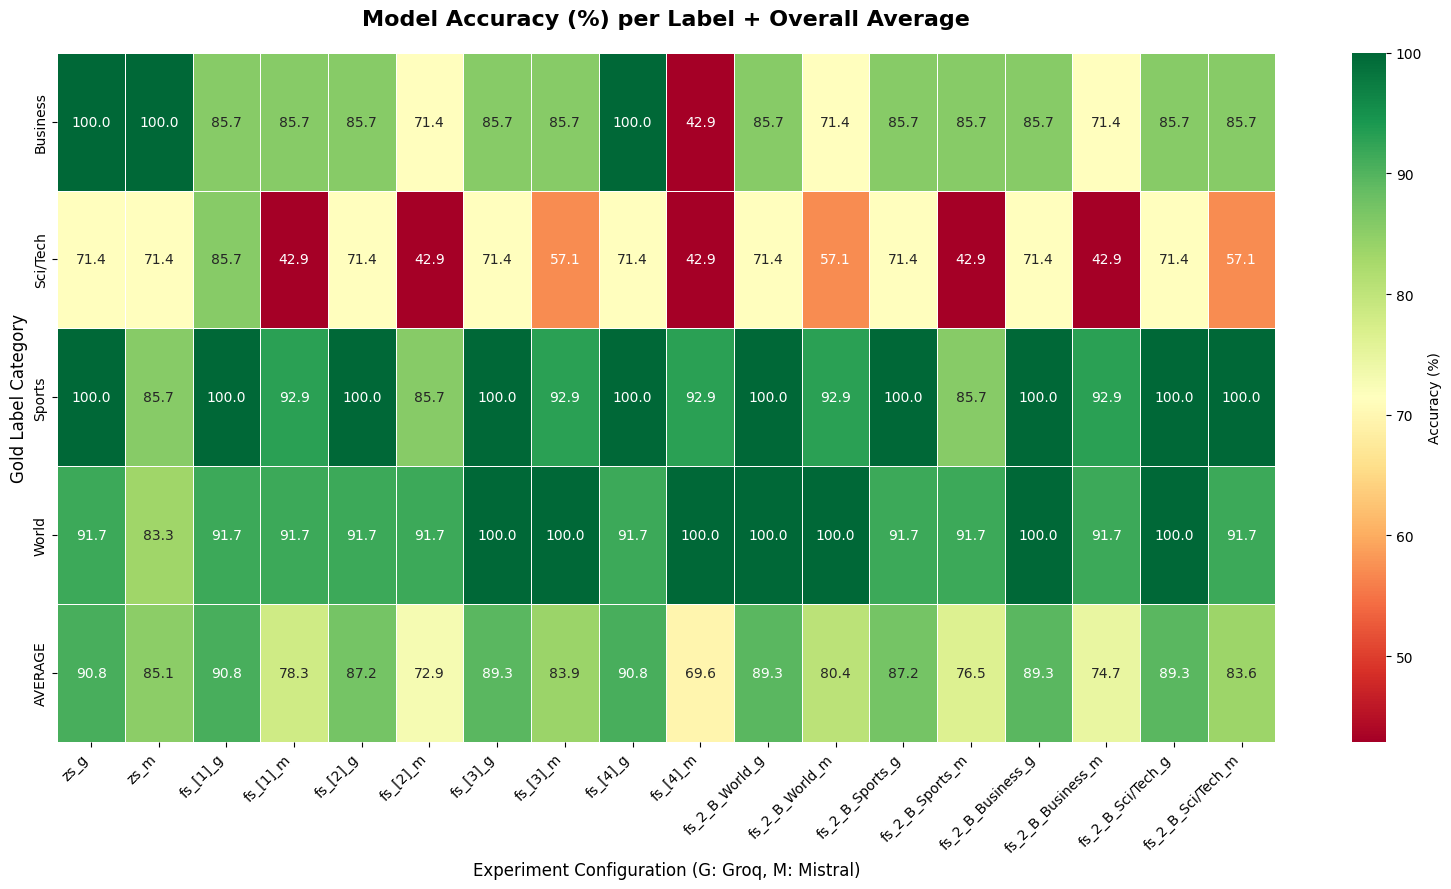

In [101]:
for idx, fs_groq_preds, fs_groq_raw, fs_groq_cost, fs_mistral_preds, fs_mistral_raw, fs_mistral_cost in zip(range(len(set_fs_groq_preds)), set_fs_groq_preds, set_fs_groq_raw, set_fs_groq_cost, set_fs_mistral_preds, set_fs_mistral_raw, set_fs_mistral_cost):
    # 5) display evaluation tables
    # 6) print the raw outputs to inspect formatting
    rows_groq = evaluate_predictions(fs_groq_preds, gold_fs)
    rows_mistral = evaluate_predictions(fs_mistral_preds, gold_fs)

    fs_preds[f"fs_[{idx+1}]_g"] = rows_groq
    fs_preds[f"fs_[{idx+1}]_m"] = rows_mistral 

    print(f"Raw outputs for few-shot with {idx+1} examples per label, and cost:")
    print("Groq raw outputs:{0}, Cost: ${1:.10f}".format(fs_groq_raw, fs_groq_cost))
    print("Mistral raw outputs:{0}, Cost: ${1:.10f}".format(fs_mistral_raw, fs_mistral_cost))

for idx, fs_groq_preds, fs_groq_raw, fs_groq_cost, fs_mistral_preds, fs_mistral_raw, fs_mistral_cost in zip(range(len(biased_set_fs_groq_preds)), biased_set_fs_groq_preds, biased_set_fs_groq_raw, biased_set_fs_groq_cost, biased_set_fs_mistral_preds, biased_set_fs_mistral_raw, biased_set_fs_mistral_cost):
    # 5) display evaluation tables
    # 6) print the raw outputs to inspect formatting
    rows_groq = evaluate_predictions(fs_groq_preds, gold_fs)
    rows_mistral = evaluate_predictions(fs_mistral_preds, gold_fs)

    fs_preds[f"fs_2_B_{LABELS[idx]}_g"] = rows_groq
    fs_preds[f"fs_2_B_{LABELS[idx]}_m"] = rows_mistral 

    print(f"Raw outputs for few-shot with 2 examples per label, Biased {LABELS[idx]}, and cost:")
    print("Groq raw outputs:{0}, Cost: ${1:.10f}".format(fs_groq_raw, fs_groq_cost))
    print("Mistral raw outputs:{0}, Cost: ${1:.10f}".format(fs_mistral_raw, fs_mistral_cost))

evaluation_table_aggregated(fs_preds)
generate_accuracy_heatmap(fs_preds)

## 7. Compare zero-shot vs few-shot

You should now have four settings:
- Groq zero-shot
- Groq few-shot
- Mistral zero-shot
- Mistral few-shot

### TODOs
- compute accuracy for each setting
- compare the numbers
- identify at least 2 error cases

,setup,accuracy
0,Groq zero-shot,0.925
1,Mistral zero-shot,0.850
2,Groq few-shot 1 ex,0.925
3,Mistral few-shot 1 ex,0.825
4,Groq few-shot 2 ex,0.900
5,Mistral few-shot 2 ex,0.775
6,Groq few-shot 3 ex,0.925
7,Mistral few-shot 3 ex,0.875
8,Groq few-shot 4 ex,0.925
9,Mistral few-shot 4 ex,0.775


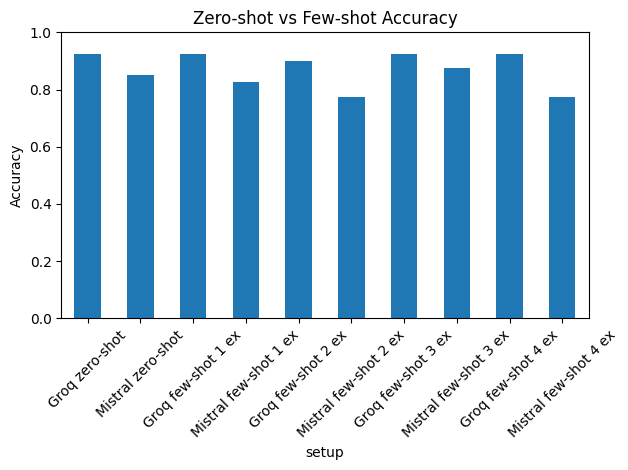

In [83]:
def accuracy(preds, gold_ids):
    # compute simple accuracy
    return sum([pred == LABELS[gold_id] for pred, gold_id in zip(preds, gold_ids)]) / len(gold_ids)

results = {
    "Groq zero-shot": accuracy(zs_groq_preds, gold),
    "Mistral zero-shot": accuracy(zs_mistral_preds, gold),
}

for idx, fs_groq_preds, fs_groq_raw, fs_mistral_preds, fs_mistral_raw in zip( range(len(set_fs_groq_preds)), set_fs_groq_preds, set_fs_groq_raw, set_fs_mistral_preds, set_fs_mistral_raw):
    acc_groq = accuracy(fs_groq_preds, gold)
    acc_mistral = accuracy(fs_mistral_preds, gold)

    results[f"Groq few-shot {idx + 1} ex"] = acc_groq
    results[f"Mistral few-shot {idx + 1} ex"] = acc_mistral

results_df = pd.DataFrame(list(results.items()), columns=["setup", "accuracy"])
display(results_df)

# optional bar plot
results_df.plot(
    kind="bar",
    x="setup",
    y="accuracy",
    legend=False,
    ylim=(0, 1),
    rot=45,
)

plt.title("Zero-shot vs Few-shot Accuracy")
plt.ylabel("Accuracy")
plt.tight_layout()
#Optional bar plot of the four accuracies

## Building a confusion matrix for the output

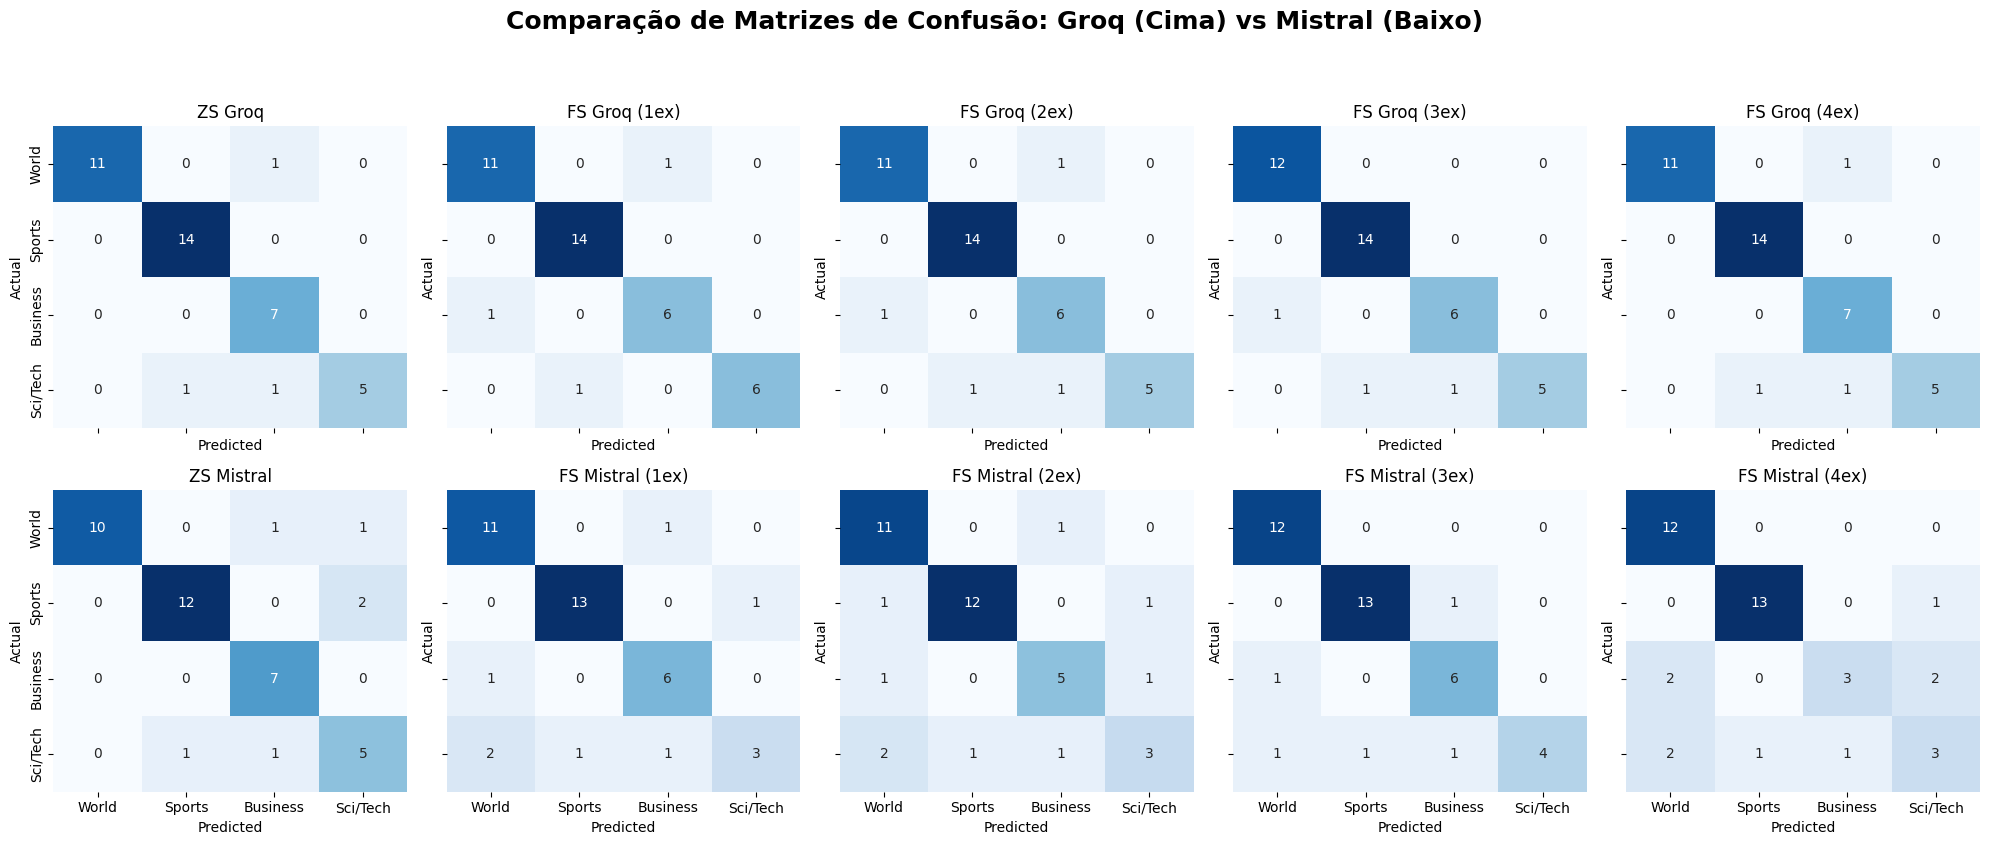

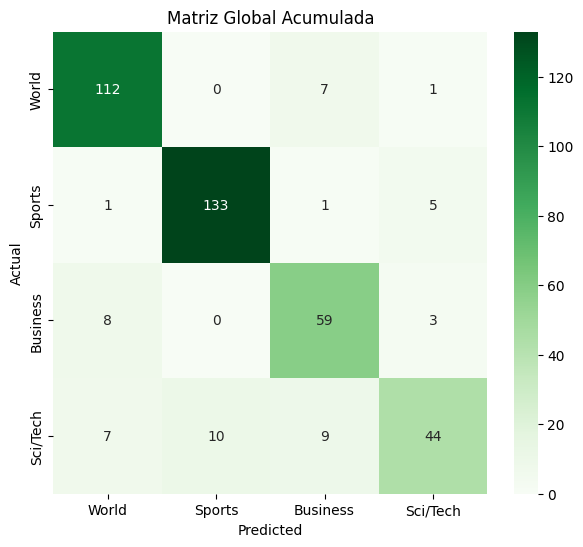

In [102]:
import matplotlib.pyplot as plt
import math

def plot_model_comparison_matrix(gold_zs, zs_groq, zs_mistral, gold_fs, fs_groq_list, fs_mistral_list):
    """
    Cria uma grade com 2 linhas:
    Linha 1: Todos os experimentos do GROQ
    Linha 2: Todos os experimentos do MISTRAL
    """
    # 1. Organizar os dados em duas listas (uma por linha)
    # Formato: (gold_data, prediction_data, title)
    row_groq = [(gold_zs, zs_groq, "ZS Groq")] + \
               [(gold_fs, p, f"FS Groq ({i+1}ex)") for i, p in enumerate(fs_groq_list)]
    
    row_mistral = [(gold_zs, zs_mistral, "ZS Mistral")] + \
                  [(gold_fs, p, f"FS Mistral ({i+1}ex)") for i, p in enumerate(fs_mistral_list)]

    num_cols = len(row_groq)
    
    # 2. Criar a figura com 2 linhas e N colunas
    fig, axes = plt.subplots(2, num_cols, figsize=(num_cols * 4, 8), sharex=True, sharey=True)

    all_matrices = []

    # 3. Plotar Linha 1 (Groq)
    for i, (gold, preds, title) in enumerate(row_groq):
        cm = build_confusion_matrix(gold, preds, title, ax=axes[0, i])
        all_matrices.append(cm)

    # 4. Plotar Linha 2 (Mistral)
    for i, (gold, preds, title) in enumerate(row_mistral):
        cm = build_confusion_matrix(gold, preds, title, ax=axes[1, i])
        all_matrices.append(cm)

    plt.suptitle("Comparação de Matrizes de Confusão: Groq (Cima) vs Mistral (Baixo)", 
                 fontsize=18, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.show()

    # --- Plot da Global ---
    plt.figure(figsize=(7, 6))
    sns.heatmap(sum(all_matrices), annot=True, fmt="d", cmap="Greens")
    plt.title("Matriz Global Acumulada")
    plt.show()

# --- Execução ---
# Certifique-se de que set_fs_groq_preds e set_fs_mistral_preds são listas de predições
plot_model_comparison_matrix(
    gold, zs_groq_preds, zs_mistral_preds, 
    gold_fs, set_fs_groq_preds, set_fs_mistral_preds
)

## 8. Reflection questions

Answer briefly in your own words.

1. Did few-shot improve performance?
> It did, but the improvement was smaller than expected.
This should really depend on the model, and problem, for these models and this problem, the examples did not have a big influence.
2. Which classes seemed easiest or hardest?
> The hardest classes were Sci/Tech and Business. The easiest was clearly Sports.
3. Were the outputs always clean and easy to parse?
>Yes for the tested models, but in the free-tier model the output was not always consistent or present.
4. How sensitive were the results to prompt wording?
>Very sensitive; early prompt attempts produced poor results.
5. What are the limitations of API-based prompting for classification?
>Mainly cost, and the lack of control or transparency over the model’s training data.
6. When would you prefer a supervised classifier instead?
>For critical or high-reliability applications.

Groq key loaded: False
Mistral key loaded: False
OpenRouter key loaded: False


## 9. Optional extensions

Choose one or more:

- Try **2 support examples per class**
> Tried up to 5 examples per class, did improve the output, but not as much as expected, and only limited to a few categories.
This should really depend on the model, and problem, for these models and this problem, the examples did not have a big influence.
- Compare **headline only** vs **full text**
> The dataset that i used, only provided text, not distinction between title and description.
- Force the model to output a **JSON object**
- Build a **confusion matrix**
> Done.
- Measure **latency** per API
- Estimate **cost / quota usage**
> It was done, on each call of the ask_fn.
- Intentionally use **biased support examples** and observe what changes

## 10. Final takeaway

Large language models can perform classification through prompting alone.

### Before finishing, make sure you completed:
- [ ] dataset loading
- [ ] zero-shot prompt
- [ ] few-shot prompt
- [ ] Groq helper
- [ ] Mistral helper
- [ ] normalization
- [ ] evaluation
- [ ] comparison
- [ ] reflection